In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import xgboost as xgb
import joblib

df = pd.read_csv("../data/creditcard.csv")
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

final_model = xgb.XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=scale_pos_weight
)
final_model.fit(X_train, y_train)

# Save the model
joblib.dump(final_model, '../models/model.pkl')
print("Model saved to ../models/model.pkl")

Model saved to ../models/model.pkl


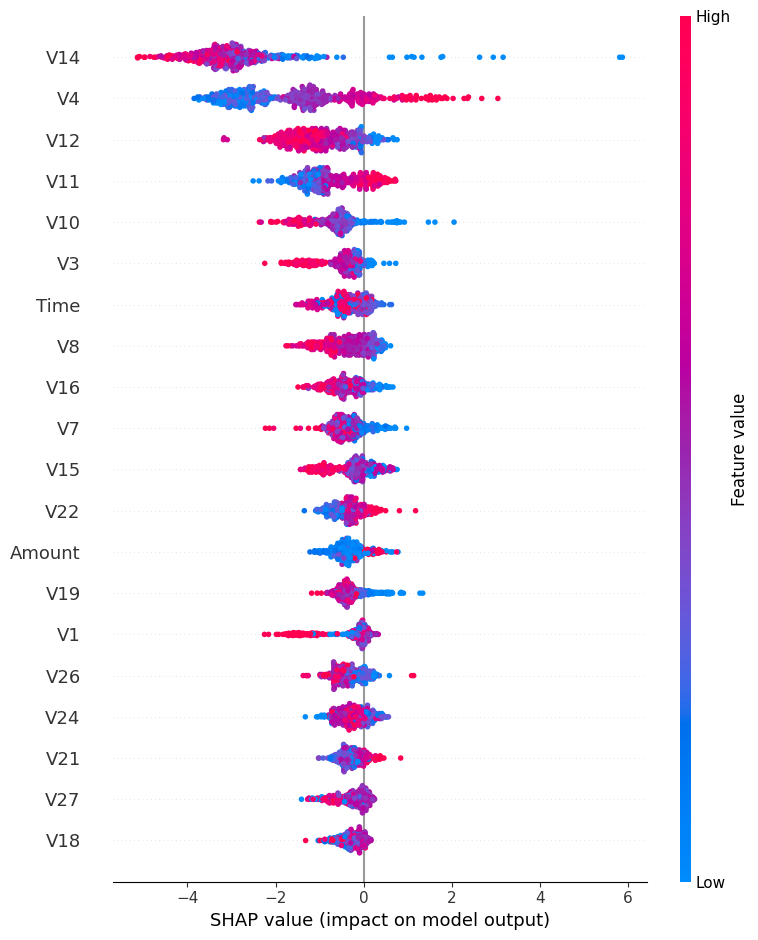

In [2]:
import shap

explainer = shap.TreeExplainer(final_model)
# Use a sample for speed (SHAP can be slow on 56k rows)
X_sample = X_test.sample(500, random_state=42)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample, show=False)
import matplotlib.pyplot as plt
plt.tight_layout()
plt.savefig('../assets/shap_summary.png')
plt.show()

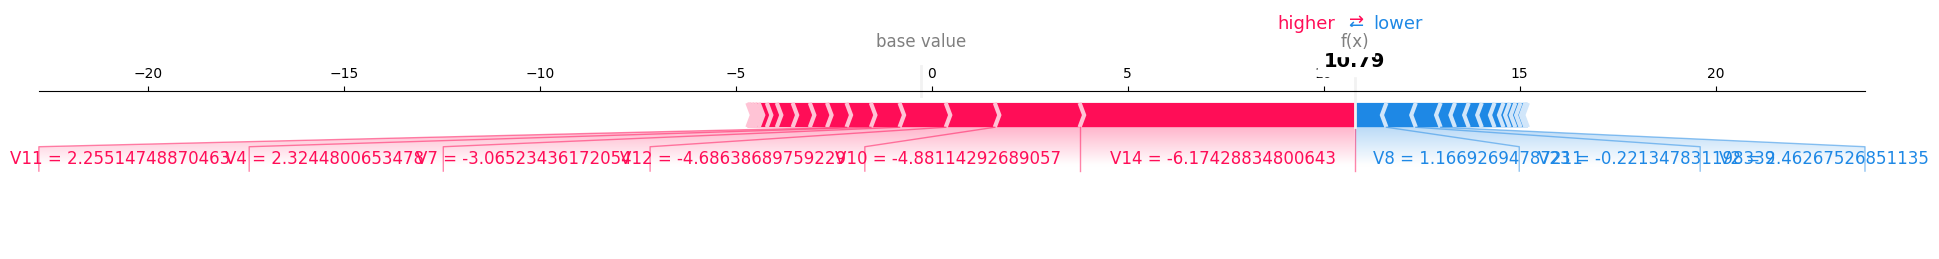

In [3]:
# Pick one fraud case from the test set
fraud_idx = y_test[y_test == 1].index[0]
sample = X_test.loc[[fraud_idx]]

shap_values_single = explainer.shap_values(sample)

shap.force_plot(
    explainer.expected_value, shap_values_single[0], sample.iloc[0],
    matplotlib=True, show=False
)
plt.tight_layout()
plt.savefig('../assets/shap_single_prediction.png')
plt.show()